In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import asyncio
from dotenv import load_dotenv

# Add project root to path so we can import app modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..'))) 
# OR if notebook is in root, just:
sys.path.append(os.getcwd())

from sqlmodel import Session, select
from database import engine
from models import Job, Application, JobStatus, ApplicationStatus
from llama_cloud_services import LlamaParse
import nest_asyncio

# Apply async patch for notebooks
nest_asyncio.apply()
load_dotenv()

print("✅ Environment & DB Modules Loaded")

✅ Environment & DB Modules Loaded


In [3]:
def get_or_create_python_job():
    with Session(engine) as session:
        # Check if job exists
        statement = select(Job).where(Job.title == "Python Intern R&D")
        existing_job = session.exec(statement).first()
        
        if existing_job:
            print(f"🔄 Job already exists: {existing_job.id}")
            return existing_job.id
        
        # Create new job
        new_job = Job(
            title="Python Intern R&D",
            raw_description="Looking for Python Expert with LangGraph and FastAPI...",
            status=JobStatus.OPEN,
            structured_rubric={} # We will fill this in Phase 3
        )
        session.add(new_job)
        session.commit()
        session.refresh(new_job)
        print(f"🆕 Created New Job: {new_job.id}")
        return new_job.id

# Run it
JOB_ID = get_or_create_python_job()

2026-01-05 12:07:34,171 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2026-01-05 12:07:34,172 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-01-05 12:07:34,191 INFO sqlalchemy.engine.Engine select current_schema()
2026-01-05 12:07:34,192 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-01-05 12:07:34,212 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2026-01-05 12:07:34,213 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-01-05 12:07:34,232 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-01-05 12:07:34,239 INFO sqlalchemy.engine.Engine SELECT jobs.id, jobs.is_deleted, jobs.created_at, jobs.updated_at, jobs.title, jobs.department, jobs.raw_description, jobs.structured_rubric, jobs.status, jobs.task_link 
FROM jobs 
WHERE jobs.title = %(title_1)s
2026-01-05 12:07:34,239 INFO sqlalchemy.engine.Engine [generated in 0.00049s] {'title_1': 'Python Intern R&D'}
🔄 Job already exists: f5c2abc9-15ee-447b-abfa-47bd95b402bb
2026-01-05 12:07:34,263 INFO sqlalchemy.engi

## **Parsing Functions**

In [4]:
async def parse_pdf(file_path: str):
    print(f"⏳ Parsing: {file_path}")
    try:
        parser = LlamaParse(
            api_key=os.getenv("LLAMA_CLOUD_API_KEY"),
            result_type="markdown", 
            verbose=False,
            language="en",
            num_workers=2
        )
        
        documents = await parser.aload_data(file_path)
        if not documents:
            return None
            
        return "\n\n".join([doc.text for doc in documents])
        
    except Exception as e:
        print(f"❌ Error Parsing {file_path}: {e}")
        return None

## **Data process and save**

In [5]:
async def process_resumes_to_db(folder_path, job_id):
    # 1. Get list of PDFs
    files = [f for f in os.listdir(folder_path) if f.endswith(".pdf")]
    
    print(f"📂 Found {len(files)} resumes in {folder_path}")
    
    with Session(engine) as session:
        for filename in files:
            file_path = os.path.join(folder_path, filename)
            
            # 2. Check if already in DB (Deduplication)
            # We check by filename for now (In prod, use file hash)
            statement = select(Application).where(Application.file_name == filename)
            existing = session.exec(statement).first()
            
            if existing:
                print(f"⏩ Skipping {filename} (Already in DB)")
                continue

            # 3. Parse (Costly Operation)
            markdown_text = await parse_pdf(file_path)
            
            if markdown_text:
                # 4. Save to DB
                new_app = Application(
                    job_id=job_id,
                    file_name=filename,
                    file_path=file_path,
                    parsed_markdown=markdown_text,
                    status=ApplicationStatus.PENDING, # Ready for Phase 3 Agent
                    score=0
                )
                session.add(new_app)
                session.commit()
                print(f"✅ Saved to DB: {filename}")
            else:
                print(f"⚠️ Failed to parse: {filename}")

# --- RUN IT ---
# Make sure you have a folder named 'data' with PDFs
await process_resumes_to_db("data", JOB_ID)

📂 Found 4 resumes in data
2026-01-05 12:07:34,350 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-01-05 12:07:34,354 INFO sqlalchemy.engine.Engine SELECT applications.id, applications.is_deleted, applications.created_at, applications.updated_at, applications.job_id, applications.file_path, applications.file_name, applications.parsed_markdown, applications.candidate_profile, applications.ai_evaluation, applications.score, applications.status, applications.edge_case_log, applications.email_draft, applications.candidate_email, applications.candidate_phone, applications.is_email_sent 
FROM applications 
WHERE applications.file_name = %(file_name_1)s
2026-01-05 12:07:34,355 INFO sqlalchemy.engine.Engine [generated in 0.00099s] {'file_name_1': 'Md-Al-Amin-Resume.pdf'}
⏳ Parsing: data/Md-Al-Amin-Resume.pdf
2026-01-05 12:07:55,472 INFO sqlalchemy.engine.Engine INSERT INTO applications (id, is_deleted, created_at, updated_at, job_id, file_path, file_name, parsed_markdown, candidate_profile,

## **Verify data**

In [6]:
with Session(engine) as session:
    statement = select(Application).where(Application.job_id == JOB_ID)
    results = session.exec(statement).all()
    
    print(f"\n📊 Total Applications in DB: {len(results)}")
    for app in results:
        print(f"ID: {app.id} | File: {app.file_name} | Status: {app.status}")
        # Show snippet of markdown to prove it worked
        print(f"Markdown Snippet: {app.parsed_markdown[:10]}...\n")

2026-01-05 12:08:47,665 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-01-05 12:08:47,667 INFO sqlalchemy.engine.Engine SELECT applications.id, applications.is_deleted, applications.created_at, applications.updated_at, applications.job_id, applications.file_path, applications.file_name, applications.parsed_markdown, applications.candidate_profile, applications.ai_evaluation, applications.score, applications.status, applications.edge_case_log, applications.email_draft, applications.candidate_email, applications.candidate_phone, applications.is_email_sent 
FROM applications 
WHERE applications.job_id = %(job_id_1)s::UUID
2026-01-05 12:08:47,667 INFO sqlalchemy.engine.Engine [generated in 0.00054s] {'job_id_1': UUID('f5c2abc9-15ee-447b-abfa-47bd95b402bb')}

📊 Total Applications in DB: 4
ID: 630cfe57-f4fe-4df3-87b4-b0fc2f5df811 | File: Md-Al-Amin-Resume.pdf | Status: ApplicationStatus.PENDING
Markdown Snippet: 
Md Al Ami...

ID: 23664b17-446f-4793-a245-cdc2b766a15b | File: Md_Oshama_B

## **Agent implementations**

In [7]:
# # --- NOTEBOOK CELL: IMPORTS & SETUP ---
# import os
# from dotenv import load_dotenv
# from langchain_openai import ChatOpenAI
# from schemas import CandidateProfile
# from prompts import EXTRACTOR_SYSTEM_PROMPT
# from graph.state import GraphState
# from sqlmodel import Session, select
# from database import engine
# from models import Application

# load_dotenv()

# # Initialize the LLM (Use GPT-4o-mini for fast, cheap extraction)
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# # Bind the Schema to the LLM (Structured Output)
# structured_llm_extractor = llm.with_structured_output(CandidateProfile)

# # --- NOTEBOOK CELL: DEFINE NODE 1 FUNCTION ---
# def extractor_node(state: GraphState) -> GraphState:
#     print(f"--- EXTRACTING PROFILE: {state['file_name']} ---")
    
#     resume_text = state["resume_markdown"]
    
#     # Create the messages payload
#     messages = [
#         ("system", EXTRACTOR_SYSTEM_PROMPT),
#         ("human", f"RESUME MARKDOWN:\n{resume_text}")
#     ]
    
#     # Invoke the LLM
#     try:
#         profile_object = structured_llm_extractor.invoke(messages)
        
#         # Convert Pydantic object to Dict for the State
#         state["extracted_profile"] = profile_object.model_dump()
#         print("✅ Extraction Successful")
        
#     except Exception as e:
#         print(f"❌ Extraction Failed: {e}")
#         state["extracted_profile"] = None
#         state["final_status"] = "ERROR"
        
#     return state


import os
import re  # <--- NEW IMPORT
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from schemas import CandidateProfile
from prompts import EXTRACTOR_SYSTEM_PROMPT
from graph.state import GraphState

load_dotenv()

# Initialize the LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Bind the Schema
structured_llm_extractor = llm.with_structured_output(CandidateProfile)

# --- HELPER: REGEX FALLBACK ---
def extract_contact_fallback(text: str):
    """
    Scans raw text for Email and Phone patterns if LLM misses them.
    """
    extracted = {}
    
    # 1. Robust Email Regex
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    emails = re.findall(email_pattern, text)
    if emails:
        # Take the first unique email found
        extracted['email'] = emails[0]

    # 2. Broad Phone Regex (Captures +880, (123), 123-456)
    # Note: This might capture dates sometimes, but it's a good safety net
    phone_pattern = r'(\+?\d{1,3}[-.\s]?)?(\(?\d{3}\)?[-.\s]?)?\d{3}[-.\s]?\d{4}'
    phones = re.findall(phone_pattern, text)
    if phones:
        # Join tuple groups if necessary, simplistic approach
        # In production, consider using the 'phonenumbers' python library
        full_match = "".join([p for p in phones[0] if isinstance(p, str)])
        if len(full_match) > 6:
            extracted['phone'] = full_match
            
    return extracted

# --- UPDATED NODE ---
def extractor_node(state: GraphState) -> GraphState:
    print(f"--- EXTRACTING PROFILE: {state['file_name']} ---")
    
    # 1. FAIL FAST: Check if text exists
    resume_text = state.get("resume_markdown")
    if not resume_text or len(resume_text) < 50:
        print("❌ EDGE CASE: Resume text is empty or too short.")
        state["final_status"] = "ERROR"
        state["edge_case_log"] = "Resume content empty (Parser failed)."
        state["extracted_profile"] = None
        return state
    
    # Create the messages payload
    messages = [
        ("system", EXTRACTOR_SYSTEM_PROMPT),
        ("human", f"RESUME MARKDOWN:\n{resume_text}")
    ]
    
    try:
        # 2. INVOKE LLM
        profile_object = structured_llm_extractor.invoke(messages)
        
        # Convert to Dict
        profile_dict = profile_object.model_dump()
        
        # 3. HYBRID CHECK (THE FIX)
        # If LLM returned None or empty string for Email/Phone, try Regex
        if not profile_dict.get("email"):
            print("⚠️ LLM missed Email. Attempting Regex Fallback...")
            fallback_data = extract_contact_fallback(resume_text)
            
            if fallback_data.get("email"):
                profile_dict["email"] = fallback_data["email"]
                print(f"✅ Regex Rescued Email: {fallback_data['email']}")
                
        if not profile_dict.get("phone"):
            # Only run regex if we didn't get it from LLM
            fallback_data = extract_contact_fallback(resume_text)
            if fallback_data.get("phone"):
                profile_dict["phone"] = fallback_data["phone"]
                print(f"✅ Regex Rescued Phone: {fallback_data['phone']}")

        # 4. SAVE TO STATE
        state["extracted_profile"] = profile_dict
        print("✅ Extraction Successful")
        
    except Exception as e:
        print(f"❌ Extraction Failed: {e}")
        state["extracted_profile"] = None
        state["final_status"] = "ERROR"
        state["edge_case_log"] = f"LLM Extraction Error: {str(e)}"
        
    return state


## **- NOTEBOOK CELL: TEST WITH REAL DB DATA -**

In [8]:


# 1. Fetch a real resume from the Database (that you saved in Phase 1)
with Session(engine) as session:
    # Get the first PENDING application
    app = session.exec(select(Application).where(Application.status == "PENDING")).first()
    
    if app:
        # 2. Initialize the Graph State with DB Data
        initial_state = GraphState(
            file_name=app.file_name,
            resume_markdown=app.parsed_markdown, # <--- The LlamaParse output
            job_description="", # Not needed for extraction node
            extracted_profile=None,
            evaluation_score=None,
            evaluation_reasoning=None,
            final_status="PROCESSING"
        )
        
        # 3. Run the Node
        updated_state = extractor_node(initial_state)
        
        # 4. View Results
        print("\n--- EXTRACTED DATA ---")
        import json
        print(json.dumps(updated_state["extracted_profile"], indent=2))
        
    else:
        print("⚠️ No pending applications found in DB to test.")

2026-01-05 12:08:48,334 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-01-05 12:08:48,335 INFO sqlalchemy.engine.Engine SELECT applications.id, applications.is_deleted, applications.created_at, applications.updated_at, applications.job_id, applications.file_path, applications.file_name, applications.parsed_markdown, applications.candidate_profile, applications.ai_evaluation, applications.score, applications.status, applications.edge_case_log, applications.email_draft, applications.candidate_email, applications.candidate_phone, applications.is_email_sent 
FROM applications 
WHERE applications.status = %(status_1)s
2026-01-05 12:08:48,335 INFO sqlalchemy.engine.Engine [generated in 0.00037s] {'status_1': 'PENDING'}
--- EXTRACTING PROFILE: Md-Al-Amin-Resume.pdf ---
✅ Extraction Successful

--- EXTRACTED DATA ---
{
  "full_name": "Md Al Amin",
  "email": "null",
  "phone": "null",
  "linkedin_url": "null",
  "github_url": "null",
  "total_years_experience": 0.5,
  "technical_skills": 

## **Evaluator node**

In [9]:
# # --- MOCK RUBRIC (Simulating DB Data) ---
# JOB_RUBRIC = {
#     "role_title": "AI & Python Backend Intern",
#     "must_have": [
#         "Python", 
#         "FastAPI", 
#         "LangChain", 
#         "LangGraph", 
#         "PostgreSQL", 
#         "OOP"
#     ],
#     "nice_to_have": [
#         "Docker", 
#         "AWS", 
#         "RAG"
#     ],
#     "min_experience": 0,  # It's an intern role
#     "domain_keywords": ["Backend", "AI", "Software Engineer"]
# }

## **Demo**

## **Demo end**

## **Job descriptions process agent**

In [10]:
# --- IMPORTS ---
from schemas import JobScoringRubric
from prompts import JD_PROCESSOR_PROMPT
from models import Job, JobStatus
from sqlmodel import Session, select
from database import engine

# --- LOAD RAW JD TEXT ---
# In production, this comes from the Frontend Text Input
with open("data-jd/jd_python_intern.txt", "r") as f:
    RAW_JD_TEXT = f.read()

# --- DEFINE THE AGENT ---
llm_jd = ChatOpenAI(model="gpt-4o", temperature=0) # Use GPT-4o for high logic accuracy
structured_llm_jd = llm_jd.with_structured_output(JobScoringRubric)

def generate_rubric_from_text(jd_text: str):
    print("🧠 Analyzing Job Description & Generating Marking Criteria...")
    
    messages = [
        ("system", JD_PROCESSOR_PROMPT),
        ("human", f"JOB DESCRIPTION:\n{jd_text}")
    ]
    
    rubric_obj = structured_llm_jd.invoke(messages)
    return rubric_obj

# --- EXECUTE ---
rubric_result = generate_rubric_from_text(RAW_JD_TEXT)

# --- VIEW THE "MARKING INSTRUCTIONS" ---
print(f"\nRole: {rubric_result.role_title}")
print(f"Min Exp: {rubric_result.min_years_experience} Years")
print("-" * 40)
print(f"{'SKILL':<20} | {'IMPORTANCE':<15} | {'POINTS':<5}")
print("-" * 40)
for item in rubric_result.skills_criteria:
    print(f"{item.skill:<20} | {item.importance:<15} | {item.weight_points:<5}")

🧠 Analyzing Job Description & Generating Marking Criteria...

Role: AI & Python Backend Intern (R&D Team)
Min Exp: 0.0 Years
----------------------------------------
SKILL                | IMPORTANCE      | POINTS
----------------------------------------
Core Python          | CRITICAL        | 25   
AI Orchestration (LangChain, LangGraph) | CRITICAL        | 25   
LLM Concepts (RAG, Multi-Agent systems, Context Engineering) | HIGH            | 15   
PostgreSQL or MySQL  | HIGH            | 15   
FastAPI or Django/Flask | HIGH            | 15   
Vector Databases (Pinecone, ChromaDB) | NICE_TO_HAVE    | 2    
Machine Learning, Deep Learning, NLP fundamentals | NICE_TO_HAVE    | 2    
Alembic for database migrations | NICE_TO_HAVE    | 2    
Problem-solving ability (DSA fundamentals) | MEDIUM          | 5    
Ability to read research papers and implement concepts | MEDIUM          | 5    
Professionalism in code documentation and Git workflow | MEDIUM          | 5    


In [11]:
def update_job_rubric(job_id, rubric_object: JobScoringRubric):
    with Session(engine) as session:
        # Fetch the job
        job = session.get(Job, job_id)
        if not job:
            print("❌ Job not found")
            return
            
        # Update the rubric column
        # .model_dump() converts Pydantic -> JSON Dict
        job.structured_rubric = rubric_object.model_dump() 
        
        session.add(job)
        session.commit()
        session.refresh(job)
        print(f"✅ Database Updated! Job '{job.title}' now has a strict scoring rubric.")

# Run update (Using the JOB_ID we created in the previous step)
update_job_rubric(JOB_ID, rubric_result)

2026-01-05 12:09:10,679 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-01-05 12:09:10,680 INFO sqlalchemy.engine.Engine SELECT jobs.id AS jobs_id, jobs.is_deleted AS jobs_is_deleted, jobs.created_at AS jobs_created_at, jobs.updated_at AS jobs_updated_at, jobs.title AS jobs_title, jobs.department AS jobs_department, jobs.raw_description AS jobs_raw_description, jobs.structured_rubric AS jobs_structured_rubric, jobs.status AS jobs_status, jobs.task_link AS jobs_task_link 
FROM jobs 
WHERE jobs.id = %(pk_1)s::UUID
2026-01-05 12:09:10,681 INFO sqlalchemy.engine.Engine [generated in 0.00056s] {'pk_1': UUID('f5c2abc9-15ee-447b-abfa-47bd95b402bb')}
2026-01-05 12:09:10,698 INFO sqlalchemy.engine.Engine UPDATE jobs SET updated_at=%(updated_at)s, structured_rubric=%(structured_rubric)s::JSON WHERE jobs.id = %(jobs_id)s::UUID
2026-01-05 12:09:10,699 INFO sqlalchemy.engine.Engine [generated in 0.00065s] {'updated_at': datetime.datetime(2026, 1, 5, 6, 9, 10, 698517), 'structured_rubric': '{"ro

In [12]:
rubric_result.model_dump()

{'role_title': 'AI & Python Backend Intern (R&D Team)',
 'summary_for_evaluator': 'The role involves developing production-grade Generative AI agents and robust backend systems using advanced orchestration frameworks.',
 'skills_criteria': [{'skill': 'Core Python',
   'importance': 'CRITICAL',
   'weight_points': 25},
  {'skill': 'AI Orchestration (LangChain, LangGraph)',
   'importance': 'CRITICAL',
   'weight_points': 25},
  {'skill': 'LLM Concepts (RAG, Multi-Agent systems, Context Engineering)',
   'importance': 'HIGH',
   'weight_points': 15},
  {'skill': 'PostgreSQL or MySQL', 'importance': 'HIGH', 'weight_points': 15},
  {'skill': 'FastAPI or Django/Flask',
   'importance': 'HIGH',
   'weight_points': 15},
  {'skill': 'Vector Databases (Pinecone, ChromaDB)',
   'importance': 'NICE_TO_HAVE',
   'weight_points': 2},
  {'skill': 'Machine Learning, Deep Learning, NLP fundamentals',
   'importance': 'NICE_TO_HAVE',
   'weight_points': 2},
  {'skill': 'Alembic for database migrations'

In [13]:
# --- IMPORTS ---
from sqlmodel import Session, select
from database import engine
from models import Job
from schemas import ScoringResult
from prompts import EVALUATOR_SYSTEM_PROMPT
from graph.state import GraphState # Ensure this is imported
import json

# 1. FETCH THE REAL RUBRIC FROM DB
def get_rubric_from_db(job_id):
    with Session(engine) as session:
        job = session.get(Job, job_id)
        if not job:
            raise ValueError("Job not found!")
        return job.structured_rubric

# Fetch the dynamic rubric
REAL_DB_RUBRIC = get_rubric_from_db(JOB_ID)
print(f"✅ Loaded Rubric for Role: {REAL_DB_RUBRIC['role_title']}")


# 2. DEFINE THE EVALUATOR NODE (With Edge Case Logic)
structured_llm_evaluator = llm.with_structured_output(ScoringResult)
# --- MOCK RUBRIC (Simulating DB Data) ---
# JOB_RUBRIC = {
#     "role_title": "AI & Python Backend Intern",
#     "must_have": [
#         "Python", 
#         "FastAPI", 
#         "LangChain", 
#         "LangGraph", 
#         "PostgreSQL", 
#         "OOP"
#     ],
#     "nice_to_have": [
#         "Docker", 
#         "AWS", 
#         "RAG"
#     ],
#     "min_experience": 0,  # It's an intern role
#     "domain_keywords": ["Backend", "AI", "Software Engineer"]
def evaluator_node(state: GraphState) -> GraphState:
    print(f"--- EVALUATING CANDIDATE ---")
    
    # --- EDGE CASE CHECK 1: MISSING PROFILE ---
    # If the Extractor failed or returned None, we cannot evaluate.
    profile = state.get("extracted_profile")
    if not profile:
        print("❌ EDGE CASE: Candidate Profile is missing.")
        state["final_status"] = "ERROR"
        state["evaluation_score"] = 0
        state["edge_case_log"] = "Evaluator skipped: Extracted Profile is None or Empty."
        return state

    # --- EDGE CASE CHECK 2: MISSING RUBRIC ---
    rubric = REAL_DB_RUBRIC 
    if not rubric:
        print("❌ EDGE CASE: Job Rubric is missing.")
        state["final_status"] = "ERROR"
        state["edge_case_log"] = "Evaluator skipped: Job Rubric could not be loaded from DB."
        return state
    
    # Create Prompt Payload
    messages = [
        ("system", EVALUATOR_SYSTEM_PROMPT),
        ("human", f"""
        JOB RUBRIC (STRICT MARKING INSTRUCTIONS):
        {json.dumps(rubric, indent=2)}
        
        CANDIDATE PROFILE:
        {json.dumps(profile, indent=2)}
        """)
    ]
    
    try:
        # Invoke LLM
        result = structured_llm_evaluator.invoke(messages)
        
        # Update State
        state["evaluation_score"] = result.score
        state["evaluation_reasoning"] = result.reasoning
        state["final_status"] = result.decision
        state["evaluation_details"] = result.model_dump()
        
        # Clear log if successful
        state["edge_case_log"] = None 
        
        print(f"✅ Evaluation Complete. Score: {result.score} | Decision: {result.decision}")
        
    except Exception as e:
        # --- EDGE CASE CHECK 3: LLM FAILURE ---
        print(f"❌ Evaluation Failed: {e}")
        state["final_status"] = "ERROR"
        state["evaluation_score"] = 0
        state["edge_case_log"] = f"LLM Evaluation Exception: {str(e)}"
        
    return state


# 3. RUN THE TEST (With Real Data)
# Ensure 'updated_state' exists from previous cells
if 'updated_state' in locals():
    final_state = evaluator_node(updated_state)

    # 4. DISPLAY RESULTS
    print("\n--- FINAL VERDICT (Based on Generated Rubric) ---")
    if final_state["final_status"] == "ERROR":
        print(f"STATUS: ERROR")
        print(f"LOG: {final_state['edge_case_log']}")
    else:
        print(f"Name: {final_state['extracted_profile']['full_name']}")
        print(f"Score: {final_state['evaluation_score']}/100")
        print(f"Status: {final_state['final_status']}")
        print(f"Reasoning: {final_state['evaluation_reasoning']}")
        print("\n--- MISSING CRITICAL SKILLS ---")
        print(final_state['evaluation_details']['missing_critical_skills'])
else:
    print("⚠️ Please run the Extractor Node first to generate 'updated_state'")

2026-01-05 12:09:10,816 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-01-05 12:09:10,816 INFO sqlalchemy.engine.Engine SELECT jobs.id AS jobs_id, jobs.is_deleted AS jobs_is_deleted, jobs.created_at AS jobs_created_at, jobs.updated_at AS jobs_updated_at, jobs.title AS jobs_title, jobs.department AS jobs_department, jobs.raw_description AS jobs_raw_description, jobs.structured_rubric AS jobs_structured_rubric, jobs.status AS jobs_status, jobs.task_link AS jobs_task_link 
FROM jobs 
WHERE jobs.id = %(pk_1)s::UUID
2026-01-05 12:09:10,817 INFO sqlalchemy.engine.Engine [cached since 0.1365s ago] {'pk_1': UUID('f5c2abc9-15ee-447b-abfa-47bd95b402bb')}
2026-01-05 12:09:10,834 INFO sqlalchemy.engine.Engine ROLLBACK
✅ Loaded Rubric for Role: AI & Python Backend Intern (R&D Team)
--- EVALUATING CANDIDATE ---
✅ Evaluation Complete. Score: 85 | Decision: SHORTLISTED

--- FINAL VERDICT (Based on Generated Rubric) ---
Name: Md Al Amin
Score: 85/100
Status: SHORTLISTED
Reasoning: The candidate po

## **Save the data into the db**

In [14]:
# def db_writer_node(state: GraphState) -> GraphState:
#     print(f"💾 SAVING RESULTS FOR: {state['file_name']}")
    
#     with Session(engine) as session:
#         # 1. FIND THE RECORD
#         # We look for the file name AND Ensure status is PENDING or PROCESSING 
#         # to avoid overwriting an old record if duplicates exist.
#         statement = select(Application).where(
#             Application.file_name == state["file_name"]
#         )
        
#         # CRITICAL FIX: Use .first() to get one object, not a list.
#         # If you accidentally used .all() or .exec() without .first(), that caused the error.
#         app_record = session.exec(statement).first()
        
#         # --- ROBUSTNESS CHECK ---
#         # If app_record is None, maybe the filename is wrong?
#         if not app_record:
#             print(f"❌ DATABASE ERROR: Could not find record for {state['file_name']}")
#             return state

#         # 2. UPDATE FIELDS
#         app_record.score = state.get("evaluation_score", 0)
#         app_record.status = state.get("final_status", "ERROR")
        
#         # Handle Edge Case Log
#         if state.get("edge_case_log"):
#              app_record.edge_case_log = state["edge_case_log"]
        
#         # Handle JSON fields (Pydantic -> Dict)
#         if state.get("extracted_profile"):
#             app_record.candidate_profile = state["extracted_profile"]
            
#         if state.get("evaluation_details"):
#             app_record.ai_evaluation = state["evaluation_details"]
            
#         # 3. COMMIT
#         session.add(app_record)
#         session.commit()
#         session.refresh(app_record)
#         print(f"✅ Database Updated! New Status: {app_record.status}")
            
#     return state


# def db_writer_node(state: GraphState) -> GraphState:
#     print(f"💾 SAVING RESULTS FOR: {state['file_name']}")
    
#     with Session(engine) as session:
#         # 1. FIND THE RECORD
#         statement = select(Application).where(
#             Application.file_name == state["file_name"]
#         )
#         app_record = session.exec(statement).first()
        
#         # --- ROBUSTNESS CHECK ---
#         if not app_record:
#             print(f"❌ DATABASE ERROR: Could not find record for {state['file_name']}")
#             return state

#         # 2. UPDATE FIELDS
#         app_record.score = state.get("evaluation_score", 0)
#         app_record.status = state.get("final_status", "ERROR")
        
#         # Log Edge Cases
#         if state.get("edge_case_log"):
#              app_record.edge_case_log = state["edge_case_log"]
        
#         # Save Extracted Profile
#         if state.get("extracted_profile"):
#             app_record.candidate_profile = state["extracted_profile"]
            
#         # Save AI Evaluation (Reasoning/Missing Skills)
#         if state.get("evaluation_details"):
#             app_record.ai_evaluation = state["evaluation_details"]

#         # --- NEW: SAVE EMAIL DRAFT ---
#         if state.get("email_draft"):
#             app_record.email_draft = state["email_draft"]
            
#         # 3. COMMIT
#         session.add(app_record)
#         session.commit()
#         session.refresh(app_record)
#         print(f"✅ Database Updated! New Status: {app_record.status}")
            
#     return state


def db_writer_node(state: GraphState) -> GraphState:
    print(f"💾 SAVING RESULTS FOR: {state['file_name']}")
    
    with Session(engine) as session:
        statement = select(Application).where(Application.file_name == state["file_name"])
        app_record = session.exec(statement).first()
        
        if not app_record:
            return state

        # Standard Fields
        app_record.score = state.get("evaluation_score", 0)
        app_record.status = state.get("final_status", "ERROR")
        if state.get("extracted_profile"):
            app_record.candidate_profile = state["extracted_profile"]
            
            # --- NEW: SAVE CONTACT INFO TO COLUMNS ---
            # This makes it easy to see emails in the DB table directly
            app_record.candidate_email = state["extracted_profile"].get("email")
            app_record.candidate_phone = state["extracted_profile"].get("phone")

        if state.get("evaluation_details"):
            app_record.ai_evaluation = state["evaluation_details"]
        if state.get("edge_case_log"):
             app_record.edge_case_log = state["edge_case_log"]

        # --- NEW: SAVE EMAIL DRAFT & SENT STATUS ---
        if state.get("email_draft"):
            app_record.email_draft = state["email_draft"]
        
        # Track if we actually sent it via MailHog
        if state.get("email_sent"):
            app_record.is_email_sent = True
            
        session.add(app_record)
        session.commit()
        session.refresh(app_record)
        print(f"✅ DB Updated. Email Sent? {app_record.is_email_sent}")
            
    return state

## **Email drafter node**

In [15]:
# --- IMPORTS ---
from schemas import EmailDraft
from prompts import HTML_EMAIL_PROMPT

# Bind schema
structured_llm_email = llm.with_structured_output(EmailDraft)

def email_generator_node(state: GraphState) -> GraphState:
    print(f"--- GENERATING EMAIL FOR: {state['final_status']} ---")
    
    # 1. Edge Case Check
    if state["final_status"] == "ERROR" or not state.get("extracted_profile"):
        return state

    # 2. Fetch Job Details (Task Link) from DB
    # In a real app, you might query this once and store in state, but querying here is fine.
    task_link = "No Link Provided"
    with Session(engine) as session:
        # Assuming you have the job_id available. For R&D batch, we use the global JOB_ID or fetch via app
        # For this snippet, we will fetch the job using the global JOB_ID we defined earlier
        job_record = session.get(Job, JOB_ID)
        if job_record and job_record.task_link:
            task_link = job_record.task_link

    # 3. Prepare Prompt Inputs
    candidate_name = state["extracted_profile"]["full_name"]
    status = state["final_status"]
    missing_skills = state['evaluation_details'].get('missing_critical_skills', [])
    
    # 4. Construct Human Message
    human_msg = f"""
    CANDIDATE: {candidate_name}
    STATUS: {status}
    MISSING SKILLS (For context only): {missing_skills}
    TASK LINK (For Shortlisted candidates): {task_link}
    """
    
    messages = [
        ("system", HTML_EMAIL_PROMPT),
        ("human", human_msg)
    ]
    
    try:
        # 5. Generate Structured Email
        email_obj = structured_llm_email.invoke(messages)
        
        # 6. Save to State (as Dict)
        state["email_draft"] = email_obj.model_dump()
        print(f"✅ Email Draft Created: {email_obj.subject}")
        
    except Exception as e:
        print(f"❌ Email Generation Error: {e}")
        state["edge_case_log"] = f"Email Gen Error: {e}"

    return state

## **Send email node**

In [16]:
from utils import send_email_via_mailhog

# def send_email_node(state: GraphState) -> GraphState:
#     print(f"--- CHECKING EMAIL SENDING LOGIC ---")
    
#     # 1. Get Data
#     status = state["final_status"]
#     draft = state.get("email_draft")
#     profile = state.get("extracted_profile")
    
#     # Safety Checks
#     if not draft or not profile or not profile.get("email"):
#         print("⚠️ Skipping Send: No draft or no email address.")
#         return state
    
#     candidate_email = profile["email"]
    
#     # 2. DECISION LOGIC
#     # We auto-send Rejections and Shortlists. 
#     # We DO NOT auto-send "REVIEW" (HR must check these manually).
    
#     should_send = False
    
#     if status == "SHORTLISTED":
#         should_send = True
#     elif status == "REJECTED":
#         should_send = True
#     elif status == "REVIEW":
#         print("⏸️ Status is REVIEW. Email saved as draft, NOT sent.")
#         should_send = False
        
#     # 3. SEND IF ALLOWED
#     if should_send:
#         success = send_email_via_mailhog(
#             to_email=candidate_email,
#             subject=draft["subject"],
#             html_body=f"{draft['body']}<br><br>{draft['signature']}"
#         )
        
#         # Update State to tell DB Writer that we sent it
#         if success:
#             state["email_sent"] = True
    
#     return state


def send_email_node(state: GraphState) -> GraphState:
    print(f"--- CHECKING EMAIL SENDING LOGIC ---")
    
    status = state["final_status"]
    draft = state.get("email_draft")
    
    # --- LOGIC CHANGE: PRIORITIZE FORM DATA ---
    # 1. Try to get email from the Form (Database)
    target_email = state.get("form_email")
    
    # 2. If Form is empty, try the LLM Extracted email (Fallback)
    if not target_email and state.get("extracted_profile"):
        target_email = state["extracted_profile"].get("email")
    
    # Safety Check
    if not draft or not target_email:
        print(f"⚠️ Skipping Send: Missing Draft or Email Address. (Target: {target_email})")
        return state
    
    # ... (Rest of logic remains the same) ...
    
    should_send = False
    if status in ["SHORTLISTED", "REJECTED"]:
        should_send = True
        
    if should_send:
        print(f"📧 Sending to: {target_email}")
        success = send_email_via_mailhog(
            to_email=target_email, # Use the robust variable
            subject=draft["subject"],
            html_body=f"{draft['body']}<br><br>{draft['signature']}"
        )
        if success:
            state["email_sent"] = True
            
    return state

## **Graph building**

In [17]:
# from langgraph.graph import StateGraph, END
# from graph.state import GraphState

# # 1. Initialize Graph
# workflow = StateGraph(GraphState)

# # 2. Add Nodes
# workflow.add_node("extractor", extractor_node)
# workflow.add_node("evaluator", evaluator_node)
# workflow.add_node("db_writer", db_writer_node)

# # 3. Define Conditional Logic (Edge Case Handling)
# def check_extraction_status(state):
#     """
#     If extraction failed (empty JSON), go to End.
#     Else, go to Evaluator.
#     """
#     if state["extracted_profile"] is None or state["final_status"] == "ERROR":
#         return "end_process"
#     return "continue"

# # 4. Add Edges (The Flow)
# workflow.set_entry_point("extractor")

# # From Extractor -> Check -> Evaluator
# workflow.add_conditional_edges(
#     "extractor",
#     check_extraction_status,
#     {
#         "continue": "evaluator",
#         "end_process": "db_writer" # Skip to save error state
#     }
# )

# # From Evaluator -> DB Saver
# workflow.add_edge("evaluator", "db_writer")

# # From DB Saver -> End
# workflow.add_edge("db_writer", END)

# # 5. Compile the Graph
# app_graph = workflow.compile()

# print("✅ LangGraph Compiled Successfully!")


# from langgraph.graph import StateGraph, END
# # Ensure you have imported all your nodes: 
# # extractor_node, evaluator_node, email_generator_node, db_writer_node

# # 1. Initialize Graph
# workflow = StateGraph(GraphState)

# # 2. Add Nodes
# workflow.add_node("extractor", extractor_node)
# workflow.add_node("evaluator", evaluator_node)
# workflow.add_node("email_gen", email_generator_node) # <--- NEW NODE
# workflow.add_node("db_writer", db_writer_node)

# # 3. Define Conditional Logic
# def check_extraction_status(state):
#     """
#     If extraction failed, skip evaluation and email generation.
#     """
#     if state["extracted_profile"] is None or state["final_status"] == "ERROR":
#         return "end_process"
#     return "continue"

# # 4. Add Edges
# workflow.set_entry_point("extractor")

# # Extractor -> (Check) -> Evaluator OR DB Writer
# workflow.add_conditional_edges(
#     "extractor",
#     check_extraction_status,
#     {
#         "continue": "evaluator",
#         "end_process": "db_writer" # Skip everything if extraction failed
#     }
# )

# # Evaluator -> Email Generator
# workflow.add_edge("evaluator", "email_gen")

# # Email Generator -> DB Writer
# workflow.add_edge("email_gen", "db_writer")

# # DB Writer -> End
# workflow.add_edge("db_writer", END)

# # 5. Compile
# app_graph = workflow.compile()

# print("✅ New LangGraph with Email Generation Compiled!")



from langgraph.graph import StateGraph, END
# Ensure 'GraphState' matches your latest definition (with 'email_sent' field)
# Ensure all nodes are defined: extractor_node, evaluator_node, email_generator_node, send_email_node, db_writer_node

# 1. Initialize Graph
workflow = StateGraph(GraphState)

# 2. Add Nodes
workflow.add_node("extractor", extractor_node)
workflow.add_node("evaluator", evaluator_node)
workflow.add_node("email_gen", email_generator_node)
workflow.add_node("email_sender", send_email_node) # <--- NEW NODE ADDED
workflow.add_node("db_writer", db_writer_node)

# 3. Define Conditional Logic
def check_extraction_status(state):
    """
    If extraction failed (empty JSON or error), skip evaluation/emails.
    Go straight to DB Writer to log the error.
    """
    # Check if profile is missing OR status is explicitly ERROR
    if not state.get("extracted_profile") or state.get("final_status") == "ERROR":
        return "end_process"
    return "continue"

# 4. Add Edges (The Pipeline Connection)
workflow.set_entry_point("extractor")

# Step 1: Extractor -> (Decision) -> Evaluator OR DB Writer
workflow.add_conditional_edges(
    "extractor",
    check_extraction_status,
    {
        "continue": "evaluator",        # Success path
        "end_process": "db_writer"      # Failure path (Skip intelligence layers)
    }
)

# Step 2: Evaluator -> Email Generator
workflow.add_edge("evaluator", "email_gen")

# Step 3: Email Generator -> Email Sender
# (Sender decides internally whether to actually send or just pass)
workflow.add_edge("email_gen", "email_sender") 

# Step 4: Email Sender -> DB Writer
# (Save the draft and the 'is_email_sent' status)
workflow.add_edge("email_sender", "db_writer")

# Step 5: DB Writer -> End
workflow.add_edge("db_writer", END)

# 5. Compile the Graph
app_graph = workflow.compile()

print("✅ Final Production Graph with MailHog Integration Compiled!")

✅ Final Production Graph with MailHog Integration Compiled!


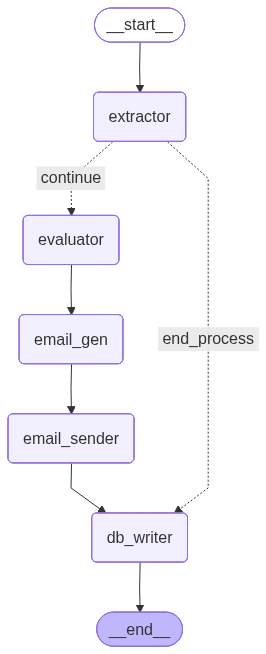

In [18]:
app_graph

## **Run the full pipeline**

In [19]:
# # # --- FETCH ALL PENDING APPLICATIONS ---
# # with Session(engine) as session:
# #     # Get ALL pending apps (returns a LIST)
# #     pending_apps = session.exec(select(Application).where(Application.status == "PENDING")).all()

# #     if not pending_apps:
# #         print("✅ No pending applications found.")
# #     else:
# #         print(f"🚀 FOUND {len(pending_apps)} RESUMES TO PROCESS...\n")

# #         # --- LOOP THROUGH EACH RESUME ---
# #         for i, app in enumerate(pending_apps):
# #             print(f"--- [{i+1}/{len(pending_apps)}] PROCESSING: {app.file_name} ---")
            
# #             # 1. Initialize State for THIS specific app
# #             initial_state = GraphState(
# #                 file_name=app.file_name,
# #                 resume_markdown=app.parsed_markdown,
# #                 job_description="", 
# #                 extracted_profile=None,
# #                 evaluation_score=0,
# #                 evaluation_reasoning=None,
# #                 final_status="PROCESSING",
# #                 evaluation_details=None,
# #                 edge_case_log=None
# #             )
            
# #             try:
# #                 # 2. RUN THE GRAPH
# #                 final_result = app_graph.invoke(initial_state)
# #                 print(f"   ✅ Finished. Status: {final_result['final_status']}")
# #             except Exception as e:
# #                 print(f"   🚨 Error processing file: {e}")
            
# #             print("-" * 50) # Separator line


# # --- FETCH ALL PENDING APPLICATIONS ---
# with Session(engine) as session:
#     # Get ALL pending apps
#     pending_apps = session.exec(select(Application).where(Application.status == "PENDING")).all()

#     if not pending_apps:
#         print("✅ No pending applications found.")
#     else:
#         print(f"🚀 FOUND {len(pending_apps)} RESUMES TO PROCESS...\n")

#         # --- LOOP THROUGH EACH RESUME ---
#         for i, app in enumerate(pending_apps):
#             print(f"--- [{i+1}/{len(pending_apps)}] PROCESSING: {app.file_name} ---")
            
#             # 1. Initialize State
#             initial_state = GraphState(
#                 file_name=app.file_name,
#                 resume_markdown=app.parsed_markdown,
#                 job_description="", 
#                 extracted_profile=None,
#                 evaluation_score=0,
#                 evaluation_reasoning=None,
#                 final_status="PROCESSING",
#                 evaluation_details=None,
#                 edge_case_log=None,
#                 email_draft=None,
#                 email_sent=False  # <--- NEW: Initialize this to False
#             )
            
#             try:
#                 # 2. RUN THE GRAPH
#                 final_result = app_graph.invoke(initial_state)
                
#                 # Print Status
#                 sent_msg = "📧 Email Sent" if final_result.get('email_sent') else "⏸️ Email Drafted (Not Sent)"
#                 print(f"   ✅ Finished. Status: {final_result['final_status']} | {sent_msg}")
                
#             except Exception as e:
#                 print(f"   🚨 Error processing file: {e}")
            
#             print("-" * 50)

In [20]:
# with Session(engine) as session:
#     # Fetch the updated record
#     updated_app = session.exec(select(Application).where(Application.file_name == app.file_name)).first()
    
#     print(f"File: {updated_app.file_name}")
#     print(f"Score: {updated_app.score}")
#     print(f"Status: {updated_app.status}")
#     print(f"AI Reasoning Snippet: {updated_app.ai_evaluation.get('reasoning')[:100]}...")

In [21]:
# --- SIMULATE FORM SUBMISSION ---
# This mimics what happens when a user types their email in the web portal.

with Session(engine) as session:
    # Find the specific resume that was failing
    # Replace 'Md_Al_Amin.pdf' with the actual filename in your DB
    statement = select(Application).where(Application.file_name.contains("Md_Al_Amin"))
    app = session.exec(statement).first()
    
    if app:
        # 1. Update the contact info directly (Simulating Form Input)
        app.candidate_email = "nsuer.alamin@gmail.com" 
        app.candidate_phone = "+880 164 104-9756"
        
        session.add(app)
        session.commit()
        print(f"✅ Form Data Simulated! Email set to: {app.candidate_email}")
    else:
        print("❌ Could not find that resume in DB.")

2026-01-05 12:09:16,076 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-01-05 12:09:16,080 INFO sqlalchemy.engine.Engine SELECT applications.id, applications.is_deleted, applications.created_at, applications.updated_at, applications.job_id, applications.file_path, applications.file_name, applications.parsed_markdown, applications.candidate_profile, applications.ai_evaluation, applications.score, applications.status, applications.edge_case_log, applications.email_draft, applications.candidate_email, applications.candidate_phone, applications.is_email_sent 
FROM applications 
WHERE (applications.file_name LIKE '%%' || %(file_name_1)s || '%%')
2026-01-05 12:09:16,081 INFO sqlalchemy.engine.Engine [generated in 0.00103s] {'file_name_1': 'Md_Al_Amin'}
2026-01-05 12:09:16,111 INFO sqlalchemy.engine.Engine UPDATE applications SET updated_at=%(updated_at)s, candidate_email=%(candidate_email)s, candidate_phone=%(candidate_phone)s WHERE applications.id = %(applications_id)s::UUID
2026-01-05 

In [22]:
# --- FETCH ALL PENDING APPLICATIONS ---
with Session(engine) as session:
    pending_apps = session.exec(select(Application).where(Application.status == "PENDING")).all()

    if not pending_apps:
        print("✅ No pending applications found.")
    else:
        print(f"🚀 FOUND {len(pending_apps)} RESUMES TO PROCESS...\n")

        for i, app in enumerate(pending_apps):
            print(f"--- [{i+1}/{len(pending_apps)}] PROCESSING: {app.file_name} ---")
            
            # 1. Initialize State
            initial_state = GraphState(
                file_name=app.file_name,
                resume_markdown=app.parsed_markdown,
                
                # --- INJECT FORM DATA HERE ---
                # This pulls "nsuer.alamin@gmail.com" from the DB row we updated in Step 1
                form_email=app.candidate_email, 
                
                job_description="", 
                extracted_profile=None,
                evaluation_score=0,
                evaluation_reasoning=None,
                final_status="PROCESSING",
                evaluation_details=None,
                edge_case_log=None,
                email_draft=None,
                email_sent=False
            )
            
            try:
                final_result = app_graph.invoke(initial_state)
                
                sent_status = "📧 Sent" if final_result.get('email_sent') else "⏸️ Draft Only"
                print(f"   ✅ Finished. Status: {final_result['final_status']} | {sent_status}")
            except Exception as e:
                print(f"   🚨 Error processing file: {e}")
            
            print("-" * 50)

2026-01-05 12:09:16,380 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-01-05 12:09:16,381 INFO sqlalchemy.engine.Engine SELECT applications.id, applications.is_deleted, applications.created_at, applications.updated_at, applications.job_id, applications.file_path, applications.file_name, applications.parsed_markdown, applications.candidate_profile, applications.ai_evaluation, applications.score, applications.status, applications.edge_case_log, applications.email_draft, applications.candidate_email, applications.candidate_phone, applications.is_email_sent 
FROM applications 
WHERE applications.status = %(status_1)s
2026-01-05 12:09:16,381 INFO sqlalchemy.engine.Engine [cached since 28.05s ago] {'status_1': 'PENDING'}
🚀 FOUND 4 RESUMES TO PROCESS...

--- [1/4] PROCESSING: Md_Oshama_Bin_Nur_Resume_Intern___Python.pdf ---
--- EXTRACTING PROFILE: Md_Oshama_Bin_Nur_Resume_Intern___Python.pdf ---
✅ Extraction Successful
--- EVALUATING CANDIDATE ---
✅ Evaluation Complete. Score: 70 | Decis